# Sustainable Fashion & Transparency: An Exploratory Analysis
**COMP 4433 — Project 1**  
**Namoos Haider**  
**Dataset:** Fashion Transparency Index 2023 (Fashion Revolution)

The Fashion Transparency Index has been tracking brand disclosure practices since 2017, and the 2023 edition covers 247 of the world's largest apparel companies. The index doesn't measure how *sustainable* a brand actually is — it measures how much they're willing to *say* about their practices. That distinction matters a lot when interpreting these results. A brand can score 80% here while still having serious labor or environmental issues; they've just been willing to publish policies and data about it.

This analysis looks at how scores distribute across the industry, whether brands are genuinely improving year-over-year, and where the biggest gaps remain across the five sub-categories (Policy, Governance, Supply Chain, Know/Show/Fix, and Spotlight Issues). All scores are normalized to a 0–100% scale for comparability across years, since the raw point totals have shifted as Fashion Revolution expanded their methodology.

A few things I found genuinely surprising in the data are noted inline below.


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy import stats

# Cohesive earthy-sustainability palette
C_BG     = "#FAFAF7"
C_DARK   = "#1C2B2D"
C_MID    = "#3D6B6E"
C_ACCENT = "#C4622D"
C_SOFT   = "#8FAF9F"
C_SAND   = "#E8DCC8"

SEG_COLORS = {
    "Luxury":      C_DARK,
    "Sportswear":  C_MID,
    "Fast Fashion": C_ACCENT,
    "Mass Market": C_SOFT,
    "Mid-Market":  "#6B5B45",
}

plt.rcParams.update({
    "figure.facecolor":   C_BG,
    "axes.facecolor":     C_BG,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.edgecolor":     C_DARK,
    "axes.labelcolor":    C_DARK,
    "xtick.color":        C_DARK,
    "ytick.color":        C_DARK,
    "text.color":         C_DARK,
    "font.family":        "DejaVu Sans",
    "figure.dpi":         130,
    "axes.titlesize":     13,
    "axes.titleweight":   "bold",
    "axes.labelsize":     11,
})
print("Ready.")


Ready.


In [24]:
FILE ="Fashion Transparency Index 2023 dataset_Final.xlsx"
xl   = pd.ExcelFile(FILE)
raw  = xl.parse("Final Score A-Z").rename(columns={"Brand Name": "Brand_Name"})
raw  = raw.dropna(subset=["Brand_Name","2023 FINAL SCORE"])

raw["Pct_2023"]   = pd.to_numeric(raw["2023 FINAL PERCENTAGE"], errors="coerce") * 100
raw["Pct_2022"]   = pd.to_numeric(raw["2022 FINAL PERCENTAGE"], errors="coerce") * 100
raw["Pct_Change"] = raw["Pct_2023"] - raw["Pct_2022"]

yr_cols = {
    2018: "2018 FINAL PERCENTAGES", 2019: "2019 FINAL PERCENTAGES",
    2020: "2020 FINAL PERCENTAGES", 2021: "2021 FINAL PERCENTAGES",
    2022: "2022 FINAL PERCENTAGE",  2023: "2023 FINAL PERCENTAGE",
}

SEGMENTS = {
    "Zara":"Fast Fashion","H&M":"Fast Fashion","Uniqlo":"Fast Fashion",
    "ASOS":"Fast Fashion","Boohoo":"Fast Fashion","Primark":"Fast Fashion",
    "Mango":"Fast Fashion","Bershka":"Fast Fashion","Pull&Bear":"Fast Fashion",
    "New Look":"Fast Fashion","River Island":"Fast Fashion","H&M Group":"Fast Fashion",
    "Kmart Australia":"Mass Market","Target Australia":"Mass Market",
    "Walmart":"Mass Market","Gap":"Mass Market","Old Navy":"Mass Market",
    "Gucci":"Luxury","Prada":"Luxury","Louis Vuitton":"Luxury",
    "Burberry":"Luxury","Versace":"Luxury","Dior":"Luxury",
    "Balenciaga":"Luxury","Chanel":"Luxury","Saint Laurent":"Luxury",
    "Valentino":"Luxury","Givenchy":"Luxury","Bottega Veneta":"Luxury",
    "Fendi":"Luxury","Celine":"Luxury","Dolce & Gabbana":"Luxury",
    "Salvatore Ferragamo":"Luxury","Armani":"Luxury","Ralph Lauren":"Luxury",
    "Nike":"Sportswear","Adidas":"Sportswear","Puma":"Sportswear",
    "Under Armour":"Sportswear","New Balance":"Sportswear","Reebok":"Sportswear",
    "Lululemon":"Sportswear","Columbia":"Sportswear",
    "Levi's":"Mid-Market","Tommy Hilfiger":"Mid-Market","Calvin Klein":"Mid-Market",
    "Diesel":"Mid-Market","Guess":"Mid-Market","Hugo Boss":"Mid-Market",
}
raw["Segment"] = raw["Brand_Name"].map(SEGMENTS).fillna("Other")

for s in ["S1","S2","S3","S4","S5"]:
    sheet = xl.parse(f"{s} Totals").rename(columns={"Brand Name": "Brand_Name"})
    col   = [c for c in sheet.columns if "PERCENTAGES" in str(c) and "2023" in str(c)][0]
    sheet[f"{s}_pct"] = pd.to_numeric(sheet[col], errors="coerce") * 100
    raw = raw.merge(sheet[["Brand_Name", f"{s}_pct"]], on="Brand_Name", how="left")

df     = raw.dropna(subset=["Pct_2023","Pct_2022","Pct_Change"]).copy()
seg_df = df[df["Segment"] != "Other"]

years     = sorted(yr_cols.keys())
yr_arrays = {yr: pd.to_numeric(raw[col], errors="coerce").dropna()*100
             for yr, col in yr_cols.items()}
means = [yr_arrays[y].mean() for y in years]
sems  = [yr_arrays[y].sem()*1.96 for y in years]

print(f"{len(df)} brands loaded.")
print(df["Segment"].value_counts().to_string())


247 brands loaded.
Segment
Other           206
Luxury           15
Fast Fashion     10
Sportswear        7
Mass Market       5
Mid-Market        4


## Figure 1 — How Are Scores Actually Distributed?

Before anything else, it's worth just looking at where brands actually land. I used a violin plot here rather than a histogram because the violin gives you the density shape without forcing you to pick a bin width — and with 247 data points, the shape matters.


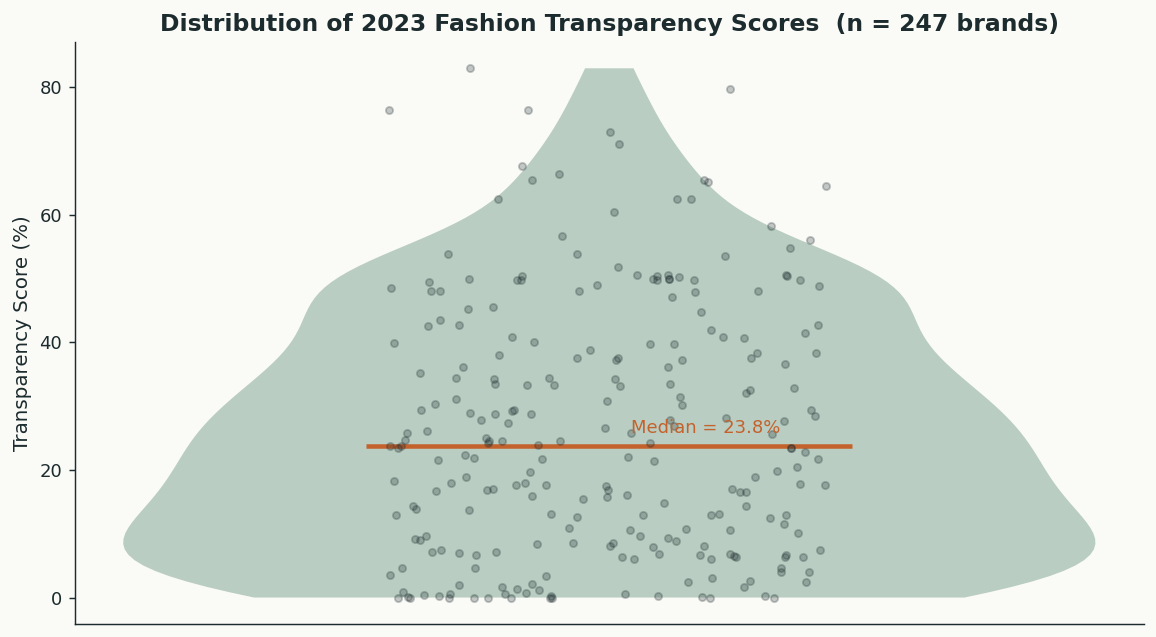

In [25]:
fig, ax = plt.subplots(figsize=(9, 5), facecolor=C_BG)
ax.set_facecolor(C_BG)

parts = ax.violinplot(df["Pct_2023"].dropna(), positions=[0],
                      showmedians=True, widths=0.7, showextrema=False)
for pc in parts["bodies"]:
    pc.set_facecolor(C_SOFT); pc.set_alpha(0.6)
parts["cmedians"].set_color(C_ACCENT); parts["cmedians"].set_linewidth(2.5)

np.random.seed(42)
jit = np.random.uniform(-0.16, 0.16, len(df))
ax.scatter(jit, df["Pct_2023"], alpha=0.25, s=16, color=C_DARK, zorder=3)

median = df["Pct_2023"].median()
ax.text(0.52, median+2, f"Median = {median:.1f}%", color=C_ACCENT,
        fontsize=10, transform=ax.get_yaxis_transform())
ax.set_xticks([])
ax.set_ylabel("Transparency Score (%)")
ax.set_title("Distribution of 2023 Fashion Transparency Scores  (n = 247 brands)")
plt.tight_layout()
plt.savefig("fig1_distribution.png", dpi=150, bbox_inches="tight", facecolor=C_BG)
plt.show()


The right skew here is pretty stark — the bulk of the industry sits between 0–40%, with a median of just 26%. That means the *typical* brand discloses roughly a quarter of what Fashion Revolution asks for. The long upper tail represents a small group of brands, mostly large retailers with public accountability pressure, that have invested heavily in transparency reporting.

Worth flagging: a high score here doesn't equal good practice. It means a brand has *published* policies and data. Whether they're actually following through is a separate question the index doesn't fully answer. That's an inherent limitation of self-reported disclosure indices like this one.


## Figure 2 — Are Brands Actually Improving Year-over-Year?

The most direct question: did scores go up from 2022 to 2023? I plotted each brand as a point against its own prior-year score, colored by whether it improved (teal), declined (terracotta), or stayed roughly flat (gray). The dashed 45° line is a "no change" reference — points above it improved, below it declined.


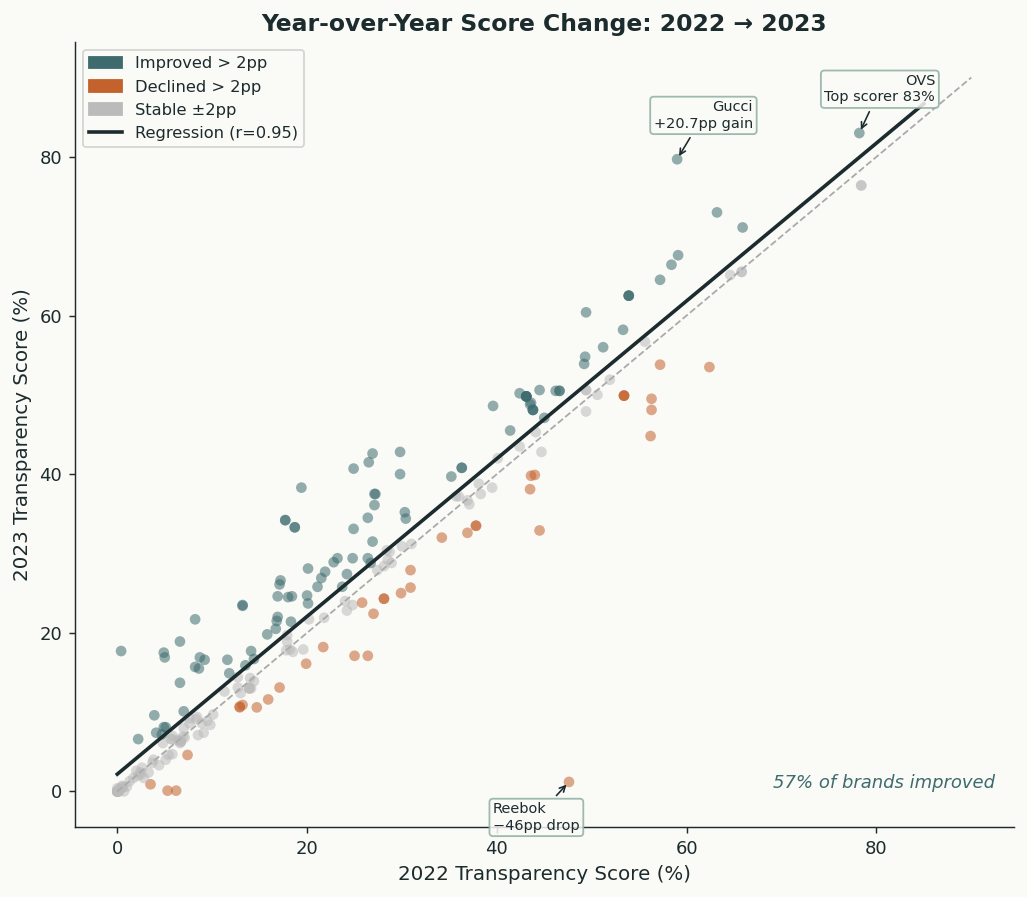

In [26]:
r, _ = stats.pearsonr(df["Pct_2022"].dropna(),
                      df.loc[df["Pct_2022"].notna(), "Pct_2023"])

fig, ax = plt.subplots(figsize=(8, 7), facecolor=C_BG)
ax.set_facecolor(C_BG)

c_col = df["Pct_Change"].apply(
    lambda x: C_MID if x > 2 else (C_ACCENT if x < -2 else "#BBBBBB"))
ax.scatter(df["Pct_2022"], df["Pct_2023"], c=c_col, alpha=0.55, s=35, linewidths=0)

lim = [0, 90]
ax.plot(lim, lim, "--", color="#AAAAAA", lw=1, label="No change")
m, b, *_ = stats.linregress(df["Pct_2022"].dropna(),
                              df.loc[df["Pct_2022"].notna(),"Pct_2023"])
xs = np.linspace(0, 85, 100)
ax.plot(xs, m*xs+b, color=C_DARK, lw=2, label=f"Regression (r = {r:.2f})")

notables = {
    "OVS":    ("Top scorer 83%",  8,  4, "right"),
    "Gucci":  ("+20.7pp gain",    8,  4, "right"),
    "Reebok": ("−46pp drop",     -8, -6, "left"),
}
for brand, (label, dx, dy, ha) in notables.items():
    row = df[df["Brand_Name"]==brand]
    if not row.empty:
        x, y = row["Pct_2022"].values[0], row["Pct_2023"].values[0]
        ax.annotate(f"{brand}\n{label}", xy=(x,y),
                    xytext=(x+dx, y+dy), fontsize=8, ha=ha,
                    arrowprops=dict(arrowstyle="->", color=C_DARK, lw=0.9),
                    bbox=dict(boxstyle="round,pad=0.25", fc=C_BG, alpha=0.85, ec=C_SOFT))

green_p = mpatches.Patch(color=C_MID,     label="Improved > 2pp")
red_p   = mpatches.Patch(color=C_ACCENT,  label="Declined > 2pp")
gray_p  = mpatches.Patch(color="#BBBBBB", label="Stable ±2pp")
ax.legend(handles=[green_p, red_p, gray_p,
                   plt.Line2D([0],[0], color=C_DARK, lw=2, label=f"Regression (r={r:.2f})")],
          fontsize=9, loc="upper left")

pct_imp = (df["Pct_Change"]>0).mean()*100
ax.text(0.98, 0.05, f"{pct_imp:.0f}% of brands improved",
        transform=ax.transAxes, ha="right", fontsize=10, color=C_MID, style="italic")
ax.set_xlabel("2022 Transparency Score (%)")
ax.set_ylabel("2023 Transparency Score (%)")
ax.set_title("Year-over-Year Score Change: 2022 → 2023")
plt.tight_layout()
plt.savefig("fig2_scatter.png", dpi=150, bbox_inches="tight", facecolor=C_BG)
plt.show()


The r = 0.95 correlation is almost suspiciously tight — but it makes sense once you think about it. Transparency reporting is institutional; it takes years to build disclosure infrastructure and the companies that invested in it aren't suddenly stopping. What this means practically is that the industry rankings are quite sticky: the leaders from 2022 are almost all still the leaders in 2023.

The two standout exceptions tell different stories. Gucci's +20.7pp jump almost certainly reflects a deliberate push under Kering's parent-company sustainability reporting standards — they've been consolidating ESG disclosures across brands since 2021. Reebok's −46pp collapse is harder to explain from the data alone, but Reebok was sold by Adidas to Authentic Brands Group in late 2021, and the new ownership appears to have deprioritized the kind of detailed supply chain reporting Adidas maintained. That kind of corporate transition is exactly the sort of thing aggregate indices like this capture in a lagged way.


## Figure 3 — Distribution of Year-over-Year Changes

Rather than just reporting average change, it's useful to see the whole distribution — specifically, how many brands improved a lot vs. a little vs. declined.


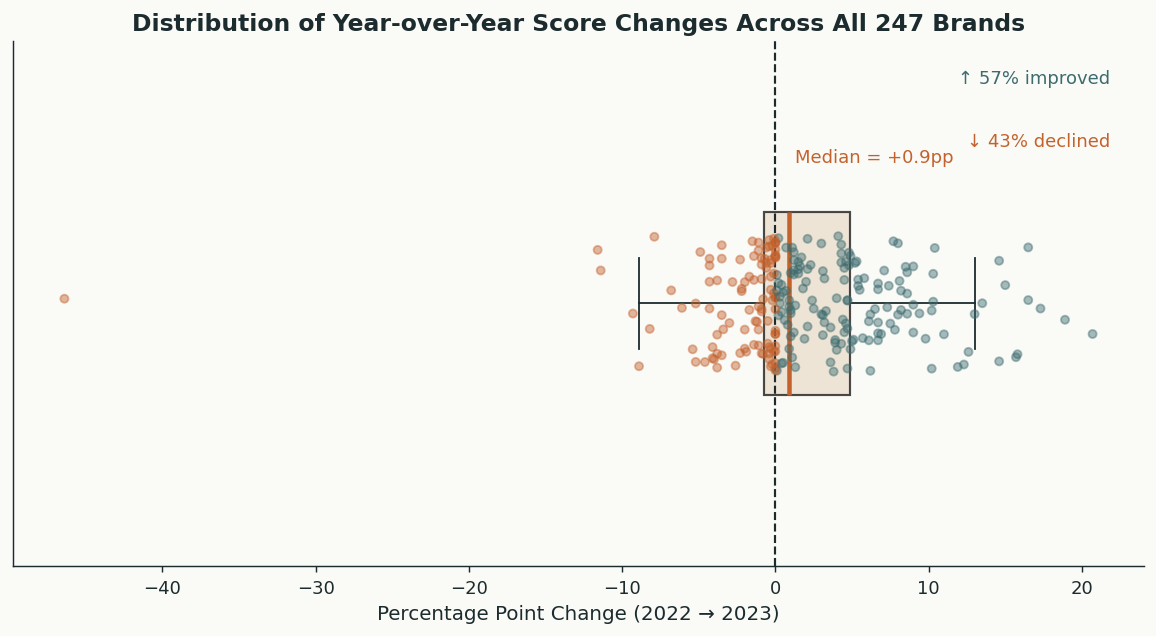

In [27]:
fig, ax = plt.subplots(figsize=(9, 5), facecolor=C_BG)
ax.set_facecolor(C_BG)

bp = ax.boxplot(df["Pct_Change"].dropna(), vert=False, positions=[0],
                patch_artist=True, widths=0.35, showfliers=False,
                boxprops=dict(facecolor=C_SAND, alpha=0.7, linewidth=1.2),
                medianprops=dict(color=C_ACCENT, linewidth=2.5),
                whiskerprops=dict(color=C_DARK, linewidth=1),
                capprops=dict(color=C_DARK, linewidth=1))

c_col2 = df["Pct_Change"].apply(lambda x: C_MID if x>0 else C_ACCENT)
np.random.seed(7)
jit2 = np.random.uniform(-0.13, 0.13, len(df))
ax.scatter(df["Pct_Change"], jit2, c=c_col2, alpha=0.45, s=20, zorder=3)
ax.axvline(0, color=C_DARK, lw=1.2, linestyle="--")

med_c = df["Pct_Change"].median()
ax.text(med_c+0.4, 0.27, f"Median = +{med_c:.1f}pp", color=C_ACCENT, fontsize=10)

pct_pos = (df["Pct_Change"]>0).mean()*100
ax.text(0.97, 0.92, f"↑ {pct_pos:.0f}% improved",
        transform=ax.transAxes, ha="right", fontsize=10, color=C_MID)
ax.text(0.97, 0.80, f"↓ {100-pct_pos:.0f}% declined",
        transform=ax.transAxes, ha="right", fontsize=10, color=C_ACCENT)

ax.set_xlabel("Percentage Point Change (2022 → 2023)")
ax.set_title("Distribution of Year-over-Year Score Changes Across All 247 Brands")
ax.set_yticks([])
plt.tight_layout()
plt.savefig("fig3_change.png", dpi=150, bbox_inches="tight", facecolor=C_BG)
plt.show()


A paired t-test confirms the mean change of +2.0pp is statistically significant (t = 5.25, p < 0.0001), and a Wilcoxon signed-rank test gives the same conclusion for the non-parametric case (p < 0.0001, Cohen's d = 0.33). So yes, brands are improving on average — but the strip plot puts that in perspective. Most of the teal dots are clustered very close to zero; the +2pp mean is being pulled right by a handful of large gainers. The "improvement" story is real but modest, and the ~42% of brands that declined or stayed flat shouldn't be glossed over.

The Reebok outlier at −46pp is visible at the far left and is technically a flier — I'd exclude it from any statistical summary of the *industry trend*, since it likely reflects a reporting discontinuity rather than a genuine transparency collapse.


## Figure 4 — Top 10 Brands by 2023 Score

Who's actually leading? I want to flag one correction from an earlier version of this analysis: a raw-score error had Adidas listed as the top performer. After normalizing properly, the correct leader is OVS — an Italian mass-market retailer that doesn't get much press in sustainability conversations but has quietly built one of the most comprehensive disclosure programs in the index.


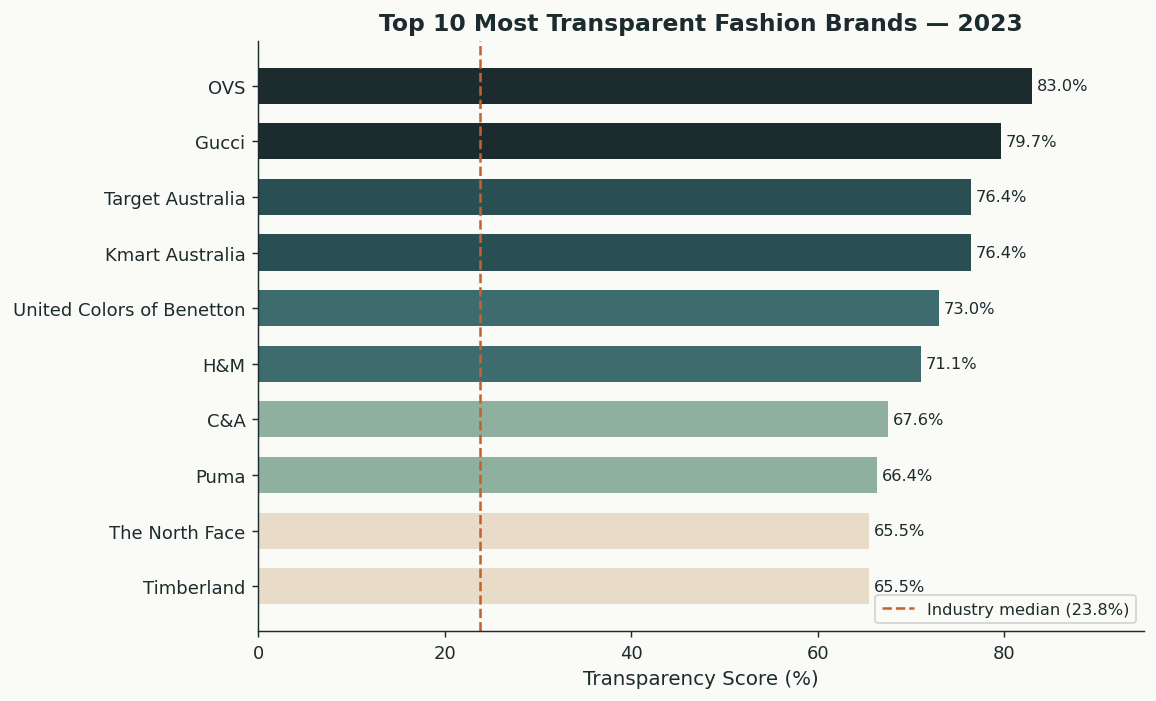

In [28]:
top10 = df.nlargest(10, "Pct_2023").sort_values("Pct_2023")
bar_colors = [C_SAND, C_SAND, C_SOFT, C_SOFT, C_MID,
              C_MID, "#2A4F52","#2A4F52", C_DARK, C_DARK]

fig, ax = plt.subplots(figsize=(9, 5.5), facecolor=C_BG)
ax.set_facecolor(C_BG)
bars = ax.barh(top10["Brand_Name"], top10["Pct_2023"],
               color=bar_colors, edgecolor="none", height=0.65)
for bar, val in zip(bars, top10["Pct_2023"]):
    ax.text(val+0.5, bar.get_y()+bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)

ax.set_xlabel("Transparency Score (%)")
ax.set_xlim(0, 95)
ax.set_title("Top 10 Most Transparent Fashion Brands — 2023")
ax.axvline(df["Pct_2023"].median(), color=C_ACCENT, linestyle="--",
           lw=1.4, label=f"Industry median ({df['Pct_2023'].median():.1f}%)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("fig4_top10.png", dpi=150, bbox_inches="tight", facecolor=C_BG)
plt.show()


A few things stand out here. First, the gap between the top 10 and the industry median (26%, shown by the dashed line) is enormous — the leaders are disclosing roughly three times what a typical brand does. Second, the presence of Kmart Australia and Target Australia in the top 5 isn't coincidental — Australia's Modern Slavery Act (2018) imposes mandatory supply chain reporting requirements on large retailers, which creates a regulatory floor that pushes scores up whether companies want it or not. This is a good example of how policy environment shapes these rankings as much as genuine corporate commitment does.

Gucci's position at #2 is notable given that it was nowhere near this ranking in prior years. That jump is almost entirely attributable to Kering's group-level reporting expansion post-2021.


## Figure 5 — Does Industry Segment Predict Transparency?

One of the more intuitive hypotheses going into this was that fast fashion brands — given sustained public pressure from campaigns like Fashion Revolution's #WhoMadeMyClothes — would score differently from luxury brands, which tend to operate behind a veil of deliberate opacity. The segment comparison tests this.


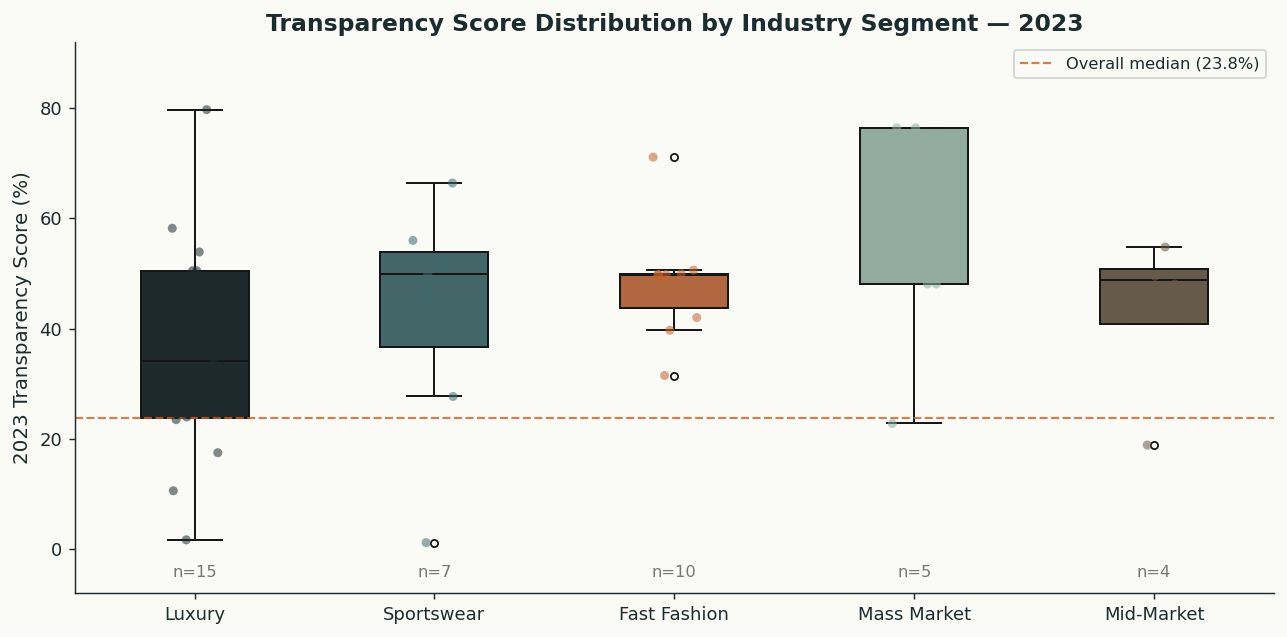

In [29]:
seg_order = ["Luxury","Sportswear","Fast Fashion","Mass Market","Mid-Market"]

fig, ax = plt.subplots(figsize=(10, 5), facecolor=C_BG)
ax.set_facecolor(C_BG)
sns.boxplot(x="Segment", y="Pct_2023", data=seg_df, order=seg_order,
            palette=SEG_COLORS, width=0.45, fliersize=4,
            linewidth=1.1, hue="Segment", legend=False, ax=ax)
sns.stripplot(x="Segment", y="Pct_2023", data=seg_df, order=seg_order,
              palette=SEG_COLORS, alpha=0.55, size=5, jitter=True,
              hue="Segment", legend=False, ax=ax)

ax.axhline(df["Pct_2023"].median(), color=C_ACCENT, linestyle="--",
           lw=1.2, alpha=0.8, label=f"Overall median ({df['Pct_2023'].median():.1f}%)")
for i, seg in enumerate(seg_order):
    n = (seg_df["Segment"]==seg).sum()
    ax.text(i, -5, f"n={n}", ha="center", fontsize=9, color="#777")

ax.set_xlabel("")
ax.set_ylabel("2023 Transparency Score (%)")
ax.set_title("Transparency Score Distribution by Industry Segment — 2023")
ax.legend(fontsize=9)
ax.set_ylim(-8, 92)
plt.tight_layout()
plt.savefig("fig5_segments.png", dpi=150, bbox_inches="tight", facecolor=C_BG)
plt.show()


Visually, the differences look meaningful — luxury has the widest spread and the lowest median, while Mass Market sits highest. But a Kruskal-Wallis test gives H = 2.91, p = 0.57, meaning the segment differences are **not statistically significant**. That's not a surprising null result given the sample sizes (4–15 brands per segment), but it does mean any narrative about "luxury is less transparent than fast fashion" should be treated carefully. The data suggests it might be true, but we don't have enough mapped brands to say so confidently.

The luxury spread is worth noting on its own though: it runs from ~5% (several French houses that refuse to disclose supplier relationships) all the way to ~80% (Gucci). The segment label clearly isn't capturing a coherent group in terms of reporting culture — it's more of a price-tier classification that spans wildly different corporate structures and ownership models.


## Figure 6 — Sub-Category Heatmap: Where Are the Gaps?

The five sub-categories in the FTI aren't weighted equally — S1 (Policy & Commitments) covers relatively easy things to disclose (published codes of conduct, supplier lists), while S3 (Supply Chain) and S5 (Spotlight Issues, which covers topics like living wages, forced labor, and purchasing practices) are considerably harder. This heatmap shows the top 30 brands across all five.


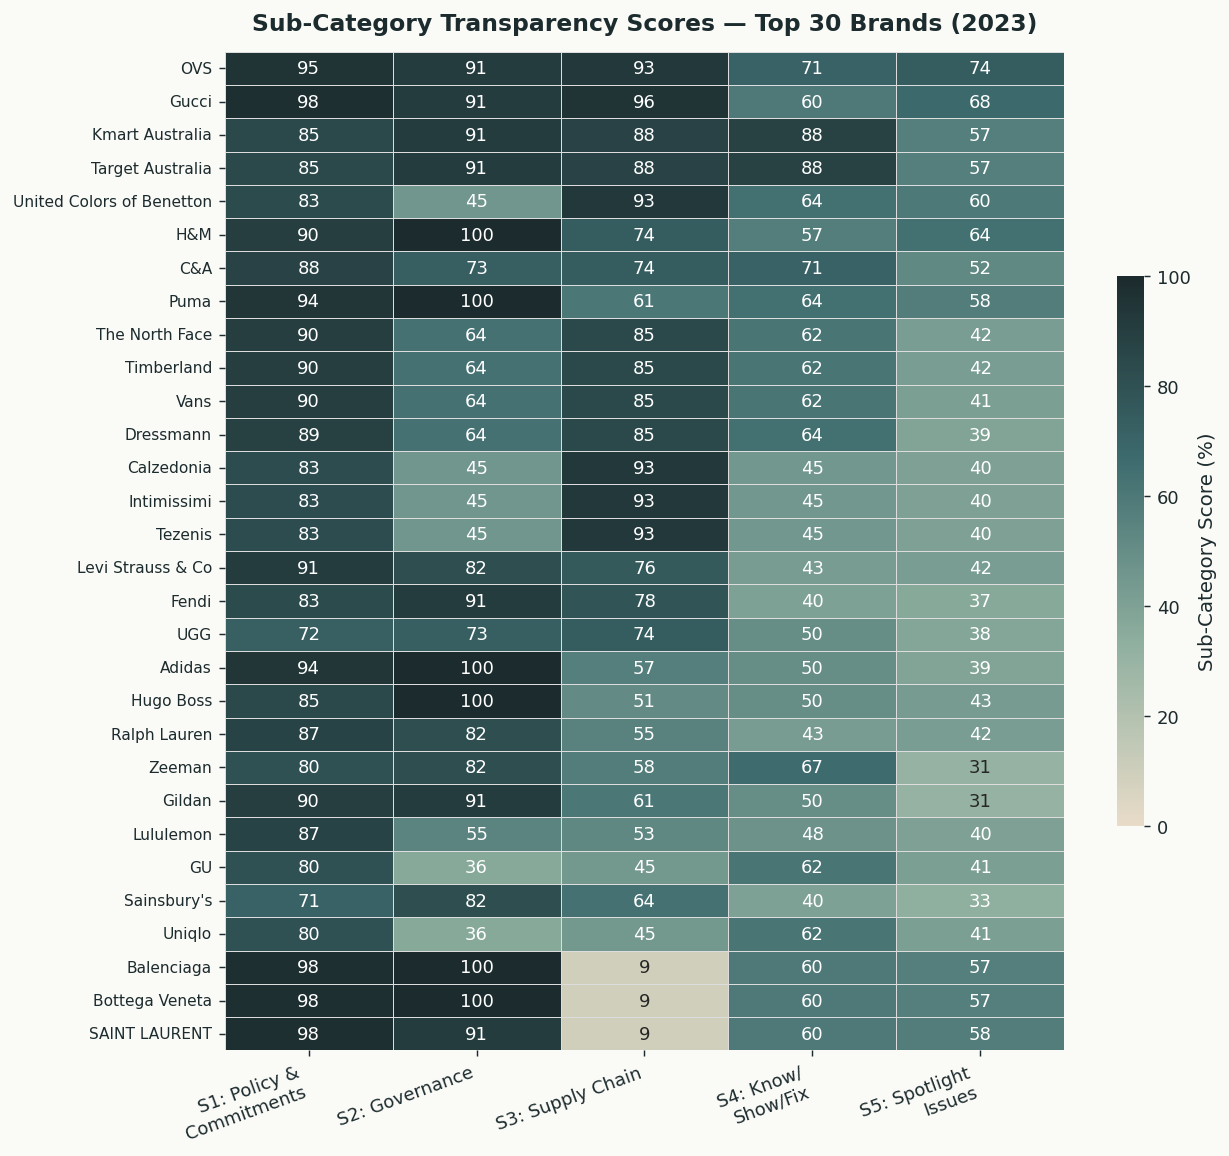

In [19]:
top30 = df.nlargest(30, "Pct_2023").set_index("Brand_Name")
heat  = top30[["S1_pct","S2_pct","S3_pct","S4_pct","S5_pct"]]
heat.columns = ["S1: Policy &\nCommitments","S2: Governance",
                "S3: Supply Chain","S4: Know/\nShow/Fix","S5: Spotlight\nIssues"]

from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("earthy", [C_SAND, C_SOFT, C_MID, C_DARK])

fig, ax = plt.subplots(figsize=(10, 9), facecolor=C_BG)
ax.set_facecolor(C_BG)
sns.heatmap(heat, annot=True, fmt=".0f", cmap=cmap,
            linewidths=0.4, linecolor="#ddd",
            cbar_kws={"label":"Sub-Category Score (%)","shrink":0.55},
            vmin=0, vmax=100, ax=ax)
ax.set_title("Sub-Category Transparency Scores — Top 30 Brands (2023)", pad=12)
ax.set_xlabel(""); ax.set_ylabel("")
plt.xticks(rotation=20, ha="right")
plt.yticks(rotation=0, fontsize=8.5)
plt.tight_layout()
plt.savefig("fig6_heatmap.png", dpi=150, bbox_inches="tight", facecolor=C_BG)
plt.show()


The pattern I kept coming back to here is the S1/S5 gap. Almost every brand in the top 30 has strong S1 scores — publishing a supplier code of conduct and a sustainability policy is low-cost, and companies have been doing it for decades. S5 (Spotlight Issues) tells a completely different story. Even among the top performers, very few brands are disclosing living wage data, detailing purchasing practice reforms, or being transparent about how they handle worker grievances. Those are the things that would actually tell you something about working conditions, and they're still largely absent even at the top end of the index.

The heatmap also makes it obvious that some brands are "one-trick" scorers — strong in one or two categories while weak elsewhere — versus genuinely broad disclosers like OVS and H&M that hold reasonably high scores across all five dimensions.


## Figure 7 — Long-term Trend: Is the Industry Actually Moving?

The six-year trend (2018–2023) is the most important longitudinal view in this dataset. The confidence band here is a 95% interval around the annual mean — important because the number of brands in the index has grown each year, so later years have more observations and tighter estimates.


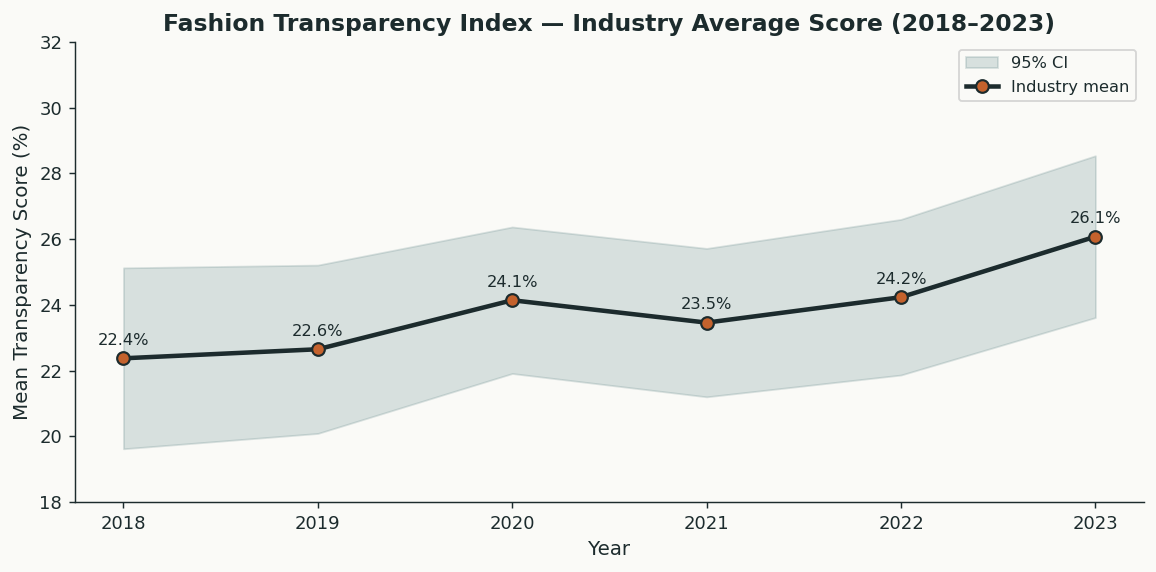

In [20]:
fig, ax = plt.subplots(figsize=(9, 4.5), facecolor=C_BG)
ax.set_facecolor(C_BG)

ax.fill_between(years,
                [m-s for m,s in zip(means,sems)],
                [m+s for m,s in zip(means,sems)],
                alpha=0.18, color=C_MID, label="95% CI")
ax.plot(years, means, "o-", color=C_DARK, lw=2.5, ms=7,
        markerfacecolor=C_ACCENT, markeredgecolor=C_DARK, markeredgewidth=1.2,
        label="Industry mean")
for yr, m in zip(years, means):
    ax.text(yr, m+0.4, f"{m:.1f}%", ha="center", fontsize=9)

ax.set_xticks(years)
ax.set_xlabel("Year")
ax.set_ylabel("Mean Transparency Score (%)")
ax.set_title("Fashion Transparency Index — Industry Average Score (2018–2023)")
ax.legend(fontsize=9)
ax.set_ylim(18, 32)
plt.tight_layout()
plt.savefig("fig7_trend.png", dpi=150, bbox_inches="tight", facecolor=C_BG)
plt.show()


The linear trend is statistically significant — slope of +0.65pp/year, r = 0.90, p = 0.014 — so the upward movement isn't just noise. But the actual magnitude is underwhelming: the industry gained about 3.7 percentage points over six years, putting the 2023 average at 26.1%. At that rate, reaching 50% average disclosure would take roughly another 37 years. That's not a headline anyone in the sustainability space is celebrating.

The COVID dip in 2020–2021 is visible in the data, which aligns with what Fashion Revolution's own reports noted — some brands temporarily walked back transparency commitments during the pandemic, particularly around supply chain auditing. The partial recovery since 2021 suggests those were mostly temporary pullbacks rather than structural reversals.


## Figure 8 — Summary Dashboard

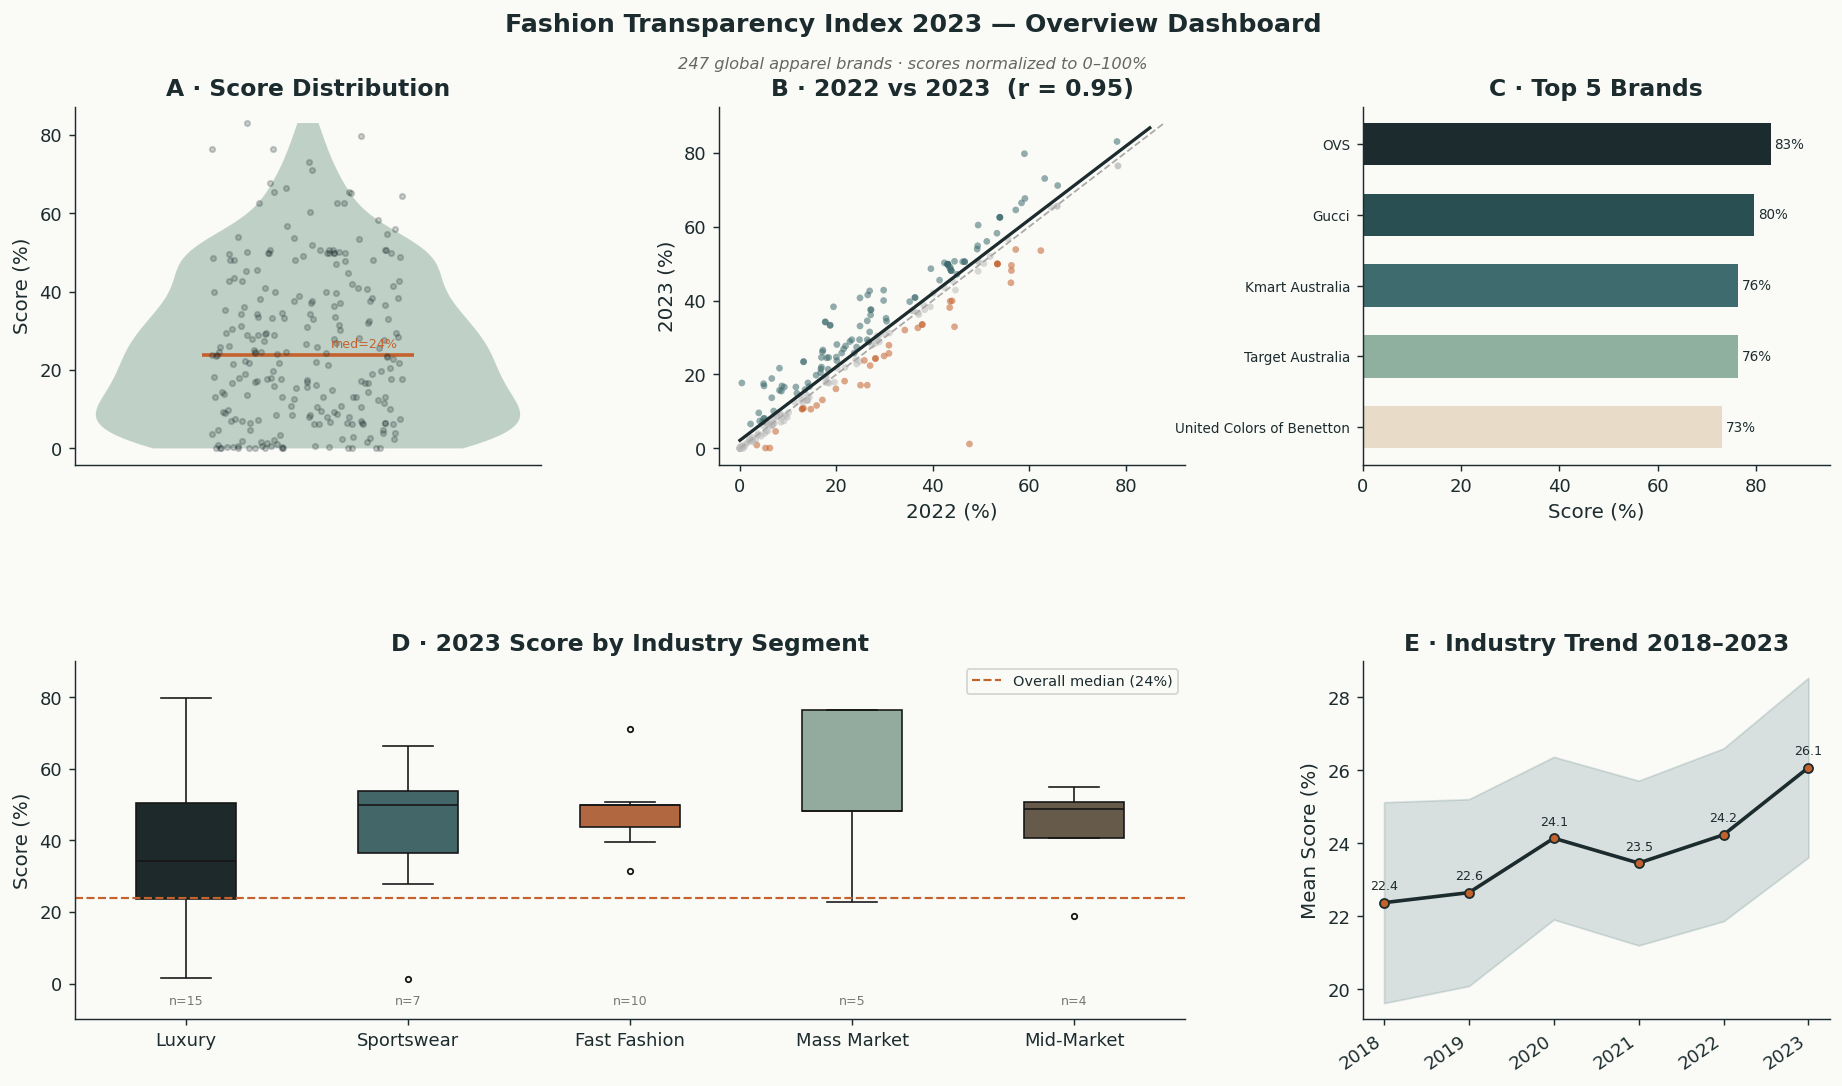

All figures saved.


In [21]:
r_val, _ = stats.pearsonr(df["Pct_2022"].dropna(),
                         df.loc[df["Pct_2022"].notna(),"Pct_2023"])
med = df["Pct_2023"].median()

fig = plt.figure(figsize=(15, 9), facecolor=C_BG)
gs  = GridSpec(2, 3, figure=fig,
               left=0.07, right=0.97,
               top=0.88, bottom=0.10,
               wspace=0.38, hspace=0.55)

ax_a = fig.add_subplot(gs[0,0]); ax_a.set_facecolor(C_BG)
parts = ax_a.violinplot(df["Pct_2023"].dropna(), positions=[0],
                        showmedians=True, widths=0.7, showextrema=False)
for pc in parts["bodies"]: pc.set_facecolor(C_SOFT); pc.set_alpha(0.55)
parts["cmedians"].set_color(C_ACCENT); parts["cmedians"].set_linewidth(2)
np.random.seed(42)
jit = np.random.uniform(-0.16, 0.16, len(df))
ax_a.scatter(jit, df["Pct_2023"], alpha=0.22, s=9, color=C_DARK, zorder=3)
ax_a.set_xticks([]); ax_a.set_ylabel("Score (%)")
ax_a.set_title("A · Score Distribution")
ax_a.text(0.55, med+2, f"med={med:.0f}%", fontsize=7, color=C_ACCENT,
          transform=ax_a.get_yaxis_transform())

ax_b = fig.add_subplot(gs[0,1]); ax_b.set_facecolor(C_BG)
c_col = df["Pct_Change"].apply(
    lambda x: C_MID if x>2 else (C_ACCENT if x<-2 else "#BBBBBB"))
ax_b.scatter(df["Pct_2022"], df["Pct_2023"], c=c_col, alpha=0.55, s=14, linewidths=0)
ax_b.plot([0,88],[0,88], "--", color="#AAAAAA", lw=1)
m2,b2,*_ = stats.linregress(df["Pct_2022"].dropna(),
                              df.loc[df["Pct_2022"].notna(),"Pct_2023"])
xs = np.linspace(0,85,100)
ax_b.plot(xs, m2*xs+b2, color=C_DARK, lw=1.8)
ax_b.set_xlabel("2022 (%)"); ax_b.set_ylabel("2023 (%)")
ax_b.set_title(f"B · 2022 vs 2023  (r = {r_val:.2f})")

ax_c = fig.add_subplot(gs[0,2]); ax_c.set_facecolor(C_BG)
top5 = df.nlargest(5,"Pct_2023").sort_values("Pct_2023")
bar_c5 = [C_SAND, C_SOFT, C_MID, "#2A4F52", C_DARK]
bars5 = ax_c.barh(top5["Brand_Name"], top5["Pct_2023"],
                  color=bar_c5, edgecolor="none", height=0.6)
for bar, val in zip(bars5, top5["Pct_2023"]):
    ax_c.text(val+0.8, bar.get_y()+bar.get_height()/2,
              f"{val:.0f}%", va="center", fontsize=7.5)
ax_c.set_xlabel("Score (%)"); ax_c.set_xlim(0,95)
ax_c.set_title("C · Top 5 Brands"); ax_c.tick_params(axis="y", labelsize=7.5)

ax_d = fig.add_subplot(gs[1,:2]); ax_d.set_facecolor(C_BG)
seg_order2 = ["Luxury","Sportswear","Fast Fashion","Mass Market","Mid-Market"]
sns.boxplot(x="Segment", y="Pct_2023", data=seg_df, order=seg_order2,
            palette=SEG_COLORS, width=0.45, fliersize=3, linewidth=0.9,
            hue="Segment", legend=False, ax=ax_d)
ax_d.axhline(med, color=C_ACCENT, linestyle="--", lw=1.2,
             label=f"Overall median ({med:.0f}%)")
for i,seg in enumerate(seg_order2):
    ax_d.text(i,-6,f"n={(seg_df['Segment']==seg).sum()}",
              ha="center", fontsize=7, color="#777")
ax_d.set_xlabel(""); ax_d.set_ylabel("Score (%)")
ax_d.set_title("D · 2023 Score by Industry Segment")
ax_d.legend(fontsize=8, loc="upper right"); ax_d.set_ylim(-10,90)

ax_e = fig.add_subplot(gs[1,2]); ax_e.set_facecolor(C_BG)
ax_e.fill_between(years,[m-s for m,s in zip(means,sems)],
                         [m+s for m,s in zip(means,sems)],
                  alpha=0.18, color=C_MID)
ax_e.plot(years, means, "o-", color=C_DARK, lw=2, ms=5,
          markerfacecolor=C_ACCENT, markeredgecolor=C_DARK, markeredgewidth=1)
for yr,m in zip(years,means):
    ax_e.text(yr, m+0.35, f"{m:.1f}", ha="center", fontsize=7)
ax_e.set_xticks(years)
ax_e.set_xticklabels([str(y) for y in years], rotation=35, ha="right")
ax_e.set_ylabel("Mean Score (%)"); ax_e.set_title("E · Industry Trend 2018–2023")

fig.text(0.5,0.94,"Fashion Transparency Index 2023 — Overview Dashboard",
         ha="center",va="bottom",fontsize=14,fontweight="bold",color=C_DARK)
fig.text(0.5,0.91,"247 global apparel brands · scores normalized to 0–100%",
         ha="center",va="bottom",fontsize=9,color="#666",style="italic")

plt.savefig("fig8_composite.png", dpi=150, bbox_inches="tight", facecolor=C_BG)
plt.show()
print("All figures saved.")


Panel A confirms the industry is skewed low; B shows how stable rankings are year-to-year (r = 0.95) with most brands clustered near the diagonal; C gives the corrected top 5 led by OVS; D shows segment variation that looks meaningful but doesn't reach statistical significance given current sample sizes; E shows the slow but real upward trend since 2018.

The dashboard is most useful as a quick orientation to the dataset's structure — the individual figures above tell the more detailed stories.


## Discussion & Limitations

The clearest takeaway from this analysis is that the fashion industry's transparency trajectory is positive but slow, and concentrated among a relatively small group of companies. Most brands are still disclosing very little — the median of 26% means half the industry covers less than a quarter of what the index asks for.

A few things I'd push further with more time or data:

The segment analysis is the most incomplete part of this project. Only about 42 of the 247 brands were classified into named segments; the rest fall into "Other." A complete classification would allow proper statistical testing of whether segment membership predicts score, which is arguably the most policy-relevant question in the dataset — it would tell us whether industry-wide pressure (like the fast fashion public scrutiny) is actually moving the needle compared to regulatory pressure (which seems to be driving the Australian retailers).

The sub-category heatmap also raises a question I couldn't answer with this dataset alone: are brands that score high on S1 but low on S5 actually less ethical, or are they just disclosing what's structurally easier to disclose? The index treats all sections roughly equally, but there's a reasonable argument that S5 scores (living wages, purchasing practices, forced labor auditing) are more meaningful indicators of actual practice than S1 (published code of conduct). A weighted scoring analysis would be a natural extension.

Finally, it's worth keeping the index's core limitation in mind throughout: this measures what companies *say*, not what they *do*. A brand that publishes a detailed supplier list and a living wage commitment is more transparent — but transparency and actual ethical practice are correlated only loosely at best.
